# Predictive Modeling: Forecasting Next-Week Gasoline Prices

This notebook builds and compares multiple models to predict next-week retail gasoline price changes.

**Models tested:**
1. Naive Baseline (no change)
2. Linear Regression (crude oil only)
3. Multiple Linear Regression (all features)
4. Ridge & Lasso Regression
5. Random Forest
6. XGBoost
7. SARIMAX (time series)

**Run after `02_Data_Cleaning.ipynb` has completed.**

In [1]:
!pip install xgboost statsmodels scikit-learn --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb

plt.rcParams.update({
    'figure.dpi': 150, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
})

Path('outputs/models').mkdir(parents=True, exist_ok=True)
print(' All imports ready')

✅ All imports ready


---
## 1. Load & Prepare Data

In [3]:
master = pd.read_csv('data/processed/master_dataset.csv', index_col=0, parse_dates=True)
print(f'Loaded: {master.shape[0]} weeks × {master.shape[1]} columns')
print(f'Date range: {master.index.min().date()} → {master.index.max().date()}')

# Identify the retail price column
price_col = 'retail_national' if 'retail_national' in master.columns else 'retail_gas_fred'
crude_col = 'wti_crude' if 'wti_crude' in master.columns else 'wti_crude_fred'
print(f'\nPrice column: {price_col}')
print(f'Crude column: {crude_col}')
print(f'Price range: ${master[price_col].min():.2f} – ${master[price_col].max():.2f}')

Loaded: 1370 weeks × 55 columns
Date range: 2000-01-03 → 2026-03-30

Price column: retail_national
Crude column: wti_crude
Price range: $1.10 – $5.11


In [4]:
# ============================================================
# CREATE PREDICTION TARGET AND FEATURES
# ============================================================

df = master.copy()

# --- Target: next week's price change ---
df['target'] = df[price_col].diff().shift(-1)  # next week's change in $/gal

# --- Ensure we have key derived features ---
# Price changes
df['retail_chg'] = df[price_col].diff()
df['retail_pct_chg'] = df[price_col].pct_change() * 100

if crude_col in df.columns:
    df['crude_chg'] = df[crude_col].diff()
    df['crude_pct_chg'] = df[crude_col].pct_change() * 100
    df['crude_per_gallon'] = df[crude_col] / 42.0
    df['crude_retail_spread'] = df[price_col] - df['crude_per_gallon']

# Spot gasoline
spot_col = None
for c in ['spot_gasoline', 'spot_gas_nyh', 'spot_gas_gulf']:
    if c in df.columns:
        spot_col = c
        df['spot_chg'] = df[c].diff()
        if 'crude_per_gallon' in df.columns:
            df['crack_spread'] = df[c] - df['crude_per_gallon']
        break

# Rolling features
df['retail_ma4'] = df[price_col].rolling(4).mean()
df['retail_ma12'] = df[price_col].rolling(12).mean()
df['retail_ma4_diff'] = df[price_col] - df['retail_ma4']  # price vs short MA
df['retail_ma12_diff'] = df[price_col] - df['retail_ma12']  # price vs long MA
df['retail_volatility'] = df['retail_chg'].rolling(12).std()

# Lagged features (previous weeks' changes)
for lag in [1, 2, 3, 4]:
    df[f'retail_chg_lag{lag}'] = df['retail_chg'].shift(lag)
    if crude_col in df.columns:
        df[f'crude_chg_lag{lag}'] = df['crude_chg'].shift(lag)

# Momentum
df['retail_momentum_4w'] = df[price_col].diff(4)  # 4-week momentum
df['retail_momentum_12w'] = df[price_col].diff(12)  # 12-week momentum

# Seasonal
df['month'] = df.index.month
df['week_of_year'] = df.index.isocalendar().week.astype(int)
df['quarter'] = df.index.quarter
df['is_summer_blend'] = df['month'].between(3, 9).astype(int)

# Stocks change
if 'gasoline_stocks' in df.columns:
    df['stocks_chg'] = df['gasoline_stocks'].diff()
    df['stocks_pct_chg'] = df['gasoline_stocks'].pct_change() * 100

print(f'\nDataset with features: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Target (next-week price change): {df["target"].notna().sum()} valid rows')


Dataset with features: 1370 rows × 76 columns
Target (next-week price change): 1369 valid rows


In [5]:
# ============================================================
# SELECT FEATURES (only what's available at prediction time)
# ============================================================

candidate_features = [
    # Current price level
    price_col,
    # Current and lagged price changes
    'retail_chg', 'retail_pct_chg',
    'retail_chg_lag1', 'retail_chg_lag2', 'retail_chg_lag3', 'retail_chg_lag4',
    # Crude oil
    crude_col, 'crude_chg', 'crude_pct_chg',
    'crude_chg_lag1', 'crude_chg_lag2', 'crude_chg_lag3', 'crude_chg_lag4',
    'crude_per_gallon', 'crude_retail_spread',
    # Spot / wholesale
    spot_col, 'spot_chg', 'crack_spread',
    # Technical
    'retail_ma4', 'retail_ma12',
    'retail_ma4_diff', 'retail_ma12_diff',
    'retail_volatility',
    'retail_momentum_4w', 'retail_momentum_12w',
    # Supply
    'gasoline_stocks', 'stocks_chg', 'stocks_pct_chg',
    # Refinery
    'refinery_util_national',
    # Macro
    'usd_index', 'consumer_sentiment', 'cpi', 'fed_funds_rate',
    'brent_crude',
    # Futures
    'crude_futures_1m', 'crude_futures_2m',
    # Seasonal
    'month', 'week_of_year', 'quarter', 'is_summer_blend',
]

# Keep only columns that actually exist
features = [f for f in candidate_features if f is not None and f in df.columns]
print(f'Selected {len(features)} features:\n')
for i, f in enumerate(features):
    print(f'  {i+1:2d}. {f}')

Selected 41 features:

   1. retail_national
   2. retail_chg
   3. retail_pct_chg
   4. retail_chg_lag1
   5. retail_chg_lag2
   6. retail_chg_lag3
   7. retail_chg_lag4
   8. wti_crude
   9. crude_chg
  10. crude_pct_chg
  11. crude_chg_lag1
  12. crude_chg_lag2
  13. crude_chg_lag3
  14. crude_chg_lag4
  15. crude_per_gallon
  16. crude_retail_spread
  17. spot_gasoline
  18. spot_chg
  19. crack_spread
  20. retail_ma4
  21. retail_ma12
  22. retail_ma4_diff
  23. retail_ma12_diff
  24. retail_volatility
  25. retail_momentum_4w
  26. retail_momentum_12w
  27. gasoline_stocks
  28. stocks_chg
  29. stocks_pct_chg
  30. refinery_util_national
  31. usd_index
  32. consumer_sentiment
  33. cpi
  34. fed_funds_rate
  35. brent_crude
  36. crude_futures_1m
  37. crude_futures_2m
  38. month
  39. week_of_year
  40. quarter
  41. is_summer_blend


In [6]:
# ============================================================
# TRAIN / TEST SPLIT (temporal — no data leakage)
# ============================================================

# Drop rows with missing target or features
model_df = df[features + ['target']].dropna()
print(f'Clean modeling dataset: {len(model_df)} rows')

# Hold out last 52 weeks (1 year) for testing
TEST_WEEKS = 52
split_idx = len(model_df) - TEST_WEEKS

train = model_df.iloc[:split_idx]
test = model_df.iloc[split_idx:]

X_train = train[features]
y_train = train['target']
X_test = test[features]
y_test = test['target']

print(f'\nTrain: {len(train)} weeks ({train.index[0].date()} → {train.index[-1].date()})')
print(f'Test:  {len(test)} weeks ({test.index[0].date()} → {test.index[-1].date()})')
print(f'\nTarget stats (train):')
print(f'  Mean: ${y_train.mean():.4f}/gal per week')
print(f'  Std:  ${y_train.std():.4f}/gal')
print(f'  Min:  ${y_train.min():.4f}, Max: ${y_train.max():.4f}')

Clean modeling dataset: 962 rows

Train: 910 weeks (2006-01-02 → 2023-06-05)
Test:  52 weeks (2023-06-12 → 2024-06-03)

Target stats (train):
  Mean: $0.0016/gal per week
  Std:  $0.0613/gal
  Min:  $-0.3300, Max: $0.4950


---
## 2. Helper Functions

In [7]:
def evaluate(y_true, y_pred, model_name):
    """Calculate all evaluation metrics."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    # Directional accuracy (did we predict up/down correctly?)
    actual_dir = (y_true > 0).astype(int)
    pred_dir = (np.array(y_pred) > 0).astype(int)
    dir_acc = (actual_dir == pred_dir).mean() * 100
    
    # Mean absolute percentage error (on non-zero actuals)
    nonzero = y_true[y_true != 0]
    if len(nonzero) > 0:
        mape = np.mean(np.abs((nonzero - y_pred[y_true != 0]) / nonzero)) * 100
    else:
        mape = np.nan
    
    return {
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'Dir. Acc (%)': dir_acc,
        'MAPE (%)': mape,
    }

# Store all results
all_results = []
all_predictions = {}

print(' Evaluation function ready')

✅ Evaluation function ready


---
## 3. Model 1: Naive Baseline (No Change)

Predicts that next week's price change = 0 (price stays the same). Any useful model must beat this.

In [8]:
naive_pred = np.zeros(len(y_test))

result = evaluate(y_test, naive_pred, 'Naive Baseline (No Change)')
all_results.append(result)
all_predictions['Naive'] = naive_pred

print('MODEL 1: Naive Baseline')
print(f'  Prediction: next week price change = $0.00')
print(f'  MAE:  ${result["MAE"]:.4f}/gal')
print(f'  RMSE: ${result["RMSE"]:.4f}/gal')
print(f'  Directional Accuracy: {result["Dir. Acc (%)"]:.1f}%')

MODEL 1: Naive Baseline
  Prediction: next week price change = $0.00
  MAE:  $0.0458/gal
  RMSE: $0.0566/gal
  Directional Accuracy: 57.7%


## 4. Model 2: Linear Regression (Crude Oil Only)

Simple model: predict gas price change from crude oil price change alone.

In [9]:
crude_features = ['crude_chg']
if all(f in X_train.columns for f in crude_features):
    lr_crude = LinearRegression()
    lr_crude.fit(X_train[crude_features], y_train)
    pred = lr_crude.predict(X_test[crude_features])
    
    result = evaluate(y_test, pred, 'Linear Regression (Crude Only)')
    all_results.append(result)
    all_predictions['LR (Crude)'] = pred
    
    print('MODEL 2: Linear Regression (Crude Oil Only)')
    print(f'  Coefficient: {lr_crude.coef_[0]:.6f}')
    print(f'  Intercept:   {lr_crude.intercept_:.6f}')
    print(f'  MAE:  ${result["MAE"]:.4f}/gal')
    print(f'  RMSE: ${result["RMSE"]:.4f}/gal')
    print(f'  R²:   {result["R²"]:.4f}')
    print(f'  Directional Accuracy: {result["Dir. Acc (%)"]:.1f}%')
else:
    print('Crude change column not available')

MODEL 2: Linear Regression (Crude Oil Only)
  Coefficient: 0.008088
  Intercept:   0.001461
  MAE:  $0.0399/gal
  RMSE: $0.0518/gal
  R²:   0.1599
  Directional Accuracy: 63.5%


## 5. Model 3: Multiple Linear Regression (All Features)

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_full = LinearRegression()
lr_full.fit(X_train_scaled, y_train)
pred = lr_full.predict(X_test_scaled)

result = evaluate(y_test, pred, 'Multiple Linear Regression')
all_results.append(result)
all_predictions['LR (Full)'] = pred

print('MODEL 3: Multiple Linear Regression (All Features)')
print(f'  MAE:  ${result["MAE"]:.4f}/gal')
print(f'  RMSE: ${result["RMSE"]:.4f}/gal')
print(f'  R²:   {result["R²"]:.4f}')
print(f'  Directional Accuracy: {result["Dir. Acc (%)"]:.1f}%')

# Feature importance by coefficient magnitude
lr_importance = pd.Series(np.abs(lr_full.coef_), index=features).sort_values(ascending=False)
print(f'\n  Top 10 features (by |coefficient|):')
for feat, imp in lr_importance.head(10).items():
    print(f'    {feat:<35} {imp:.6f}')

MODEL 3: Multiple Linear Regression (All Features)
  MAE:  $0.0460/gal
  RMSE: $0.0573/gal
  R²:   -0.0252
  Directional Accuracy: 63.5%

  Top 10 features (by |coefficient|):
    retail_ma4_diff                     1516079516319.928223
    retail_chg                          789199821872.215820
    retail_national                     772061856027.189087
    retail_chg_lag1                     484707424091.281555
    retail_momentum_4w                  390073624349.684998
    retail_ma4                          352443353976.904053
    retail_chg_lag2                     180275052315.212494
    retail_ma12                         141614108703.864532
    retail_chg_lag3                     124126336067.131256
    crude_retail_spread                 124009341072.039398


## 6. Model 4 & 5: Ridge & Lasso Regression

Regularized versions that prevent overfitting.

In [11]:
# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
pred_ridge = ridge.predict(X_test_scaled)

result = evaluate(y_test, pred_ridge, 'Ridge Regression')
all_results.append(result)
all_predictions['Ridge'] = pred_ridge

print('MODEL 4: Ridge Regression')
print(f'  MAE: ${result["MAE"]:.4f}  |  RMSE: ${result["RMSE"]:.4f}  |  R²: {result["R²"]:.4f}  |  Dir: {result["Dir. Acc (%)"]:.1f}%')

# Lasso Regression
lasso = Lasso(alpha=0.001)
lasso.fit(X_train_scaled, y_train)
pred_lasso = lasso.predict(X_test_scaled)

result = evaluate(y_test, pred_lasso, 'Lasso Regression')
all_results.append(result)
all_predictions['Lasso'] = pred_lasso

print(f'\nMODEL 5: Lasso Regression')
print(f'  MAE: ${result["MAE"]:.4f}  |  RMSE: ${result["RMSE"]:.4f}  |  R²: {result["R²"]:.4f}  |  Dir: {result["Dir. Acc (%)"]:.1f}%')

# Show which features Lasso kept (non-zero coefficients)
lasso_coefs = pd.Series(lasso.coef_, index=features)
kept = lasso_coefs[lasso_coefs != 0]
dropped = lasso_coefs[lasso_coefs == 0]
print(f'\n  Lasso kept {len(kept)}/{len(features)} features, dropped {len(dropped)}')
print(f'  Dropped features: {dropped.index.tolist()}')

MODEL 4: Ridge Regression
  MAE: $0.0402  |  RMSE: $0.0491  |  R²: 0.2462  |  Dir: 69.2%

MODEL 5: Lasso Regression
  MAE: $0.0326  |  RMSE: $0.0430  |  R²: 0.4205  |  Dir: 76.9%

  Lasso kept 19/41 features, dropped 22
  Dropped features: ['retail_national', 'retail_pct_chg', 'retail_chg_lag1', 'retail_chg_lag3', 'retail_chg_lag4', 'wti_crude', 'crude_chg_lag3', 'crude_per_gallon', 'spot_gasoline', 'crack_spread', 'retail_ma12', 'retail_ma12_diff', 'retail_momentum_4w', 'retail_momentum_12w', 'stocks_chg', 'refinery_util_national', 'usd_index', 'cpi', 'fed_funds_rate', 'brent_crude', 'crude_futures_1m', 'crude_futures_2m']


## 7. Model 6: Random Forest

In [12]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

result = evaluate(y_test, pred_rf, 'Random Forest')
all_results.append(result)
all_predictions['Random Forest'] = pred_rf

print('MODEL 6: Random Forest')
print(f'  MAE: ${result["MAE"]:.4f}  |  RMSE: ${result["RMSE"]:.4f}  |  R²: {result["R²"]:.4f}  |  Dir: {result["Dir. Acc (%)"]:.1f}%')

# Feature importance
rf_importance = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print(f'\n  Top 10 features:')
for feat, imp in rf_importance.head(10).items():
    print(f'    {feat:<35} {imp:.4f}')

MODEL 6: Random Forest
  MAE: $0.0360  |  RMSE: $0.0470  |  R²: 0.3081  |  Dir: 78.8%

  Top 10 features:
    retail_chg                          0.3848
    retail_pct_chg                      0.1941
    spot_chg                            0.0320
    gasoline_stocks                     0.0211
    crude_chg_lag1                      0.0196
    week_of_year                        0.0192
    crude_chg_lag4                      0.0189
    refinery_util_national              0.0188
    crude_chg_lag3                      0.0180
    stocks_chg                          0.0170


## 8. Model 7: XGBoost (Gradient Boosting)

Typically the strongest model for tabular data with mixed feature types.

In [13]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0,
    early_stopping_rounds=50,
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

pred_xgb = xgb_model.predict(X_test)

result = evaluate(y_test, pred_xgb, 'XGBoost')
all_results.append(result)
all_predictions['XGBoost'] = pred_xgb

print('MODEL 7: XGBoost')
print(f'  MAE: ${result["MAE"]:.4f}  |  RMSE: ${result["RMSE"]:.4f}  |  R²: {result["R²"]:.4f}  |  Dir: {result["Dir. Acc (%)"]:.1f}%')
print(f'  Best iteration: {xgb_model.best_iteration}')

# Feature importance
xgb_importance = pd.Series(xgb_model.feature_importances_, index=features).sort_values(ascending=False)
print(f'\n  Top 10 features:')
for feat, imp in xgb_importance.head(10).items():
    print(f'    {feat:<35} {imp:.4f}')

MODEL 7: XGBoost
  MAE: $0.0358  |  RMSE: $0.0468  |  R²: 0.3151  |  Dir: 75.0%
  Best iteration: 52

  Top 10 features:
    retail_chg                          0.1967
    retail_pct_chg                      0.1482
    retail_ma4_diff                     0.0697
    spot_chg                            0.0275
    crude_futures_2m                    0.0272
    month                               0.0268
    brent_crude                         0.0246
    stocks_pct_chg                      0.0234
    week_of_year                        0.0210
    crude_pct_chg                       0.0201


## 9. Model 8: SARIMAX (Time Series)

Statistical time series model with exogenous variables.

In [14]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Use a smaller set of exogenous variables for SARIMAX
sarimax_exog = [c for c in ['crude_chg', 'is_summer_blend'] if c in df.columns]

# Prepare data
ts_data = df[[price_col] + sarimax_exog].dropna()
ts_train = ts_data.iloc[:-TEST_WEEKS]
ts_test = ts_data.iloc[-TEST_WEEKS:]

print(f'SARIMAX data: {len(ts_train)} train, {len(ts_test)} test')
print(f'Exogenous variables: {sarimax_exog}')
print('\nFitting SARIMAX(1,1,1)... (this may take a minute)')

try:
    sarimax = SARIMAX(
        ts_train[price_col],
        exog=ts_train[sarimax_exog] if sarimax_exog else None,
        order=(1, 1, 1),
        seasonal_order=(1, 0, 0, 52),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    sarimax_fit = sarimax.fit(disp=False, maxiter=200)
    
    # Forecast
    forecast = sarimax_fit.forecast(
        steps=TEST_WEEKS,
        exog=ts_test[sarimax_exog] if sarimax_exog else None,
    )
    
    # Convert to price changes for comparison
    actual_prices = ts_test[price_col].values
    forecast_prices = forecast.values
    
    # Align with our test set target
    common_idx = y_test.index.intersection(ts_test.index)
    if len(common_idx) >= TEST_WEEKS - 5:
        # Calculate predicted price changes from SARIMAX forecasted levels
        forecast_series = pd.Series(forecast_prices, index=ts_test.index)
        last_known = ts_train[price_col].iloc[-1]
        pred_sarimax_changes = np.diff(np.concatenate([[last_known], forecast_prices]))
        pred_sarimax_changes = pred_sarimax_changes[:len(y_test)]
        
        result = evaluate(y_test.values[:len(pred_sarimax_changes)], 
                         pred_sarimax_changes, 'SARIMAX(1,1,1)')
        all_results.append(result)
        all_predictions['SARIMAX'] = pred_sarimax_changes
        
        print(f'\nMODEL 8: SARIMAX(1,1,1)')
        print(f'  MAE: ${result["MAE"]:.4f}  |  RMSE: ${result["RMSE"]:.4f}  |  R²: {result["R²"]:.4f}  |  Dir: {result["Dir. Acc (%)"]:.1f}%')
        print(f'  AIC: {sarimax_fit.aic:.1f}  |  BIC: {sarimax_fit.bic:.1f}')
    else:
        print('Could not align SARIMAX forecast with test set')
        
except Exception as e:
    print(f'SARIMAX failed: {e}')
    print('Continuing with other models...')

SARIMAX data: 1317 train, 52 test
Exogenous variables: ['crude_chg', 'is_summer_blend']

Fitting SARIMAX(1,1,1)... (this may take a minute)


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


Could not align SARIMAX forecast with test set


---
## 10. Model Comparison Results

In [22]:
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('MAE')

print('=' * 90)
print('MODEL COMPARISON — Predicting Next-Week Gasoline Price Change')
print('=' * 90)
print(results_df.to_string(index=False, float_format='%.4f'))
print('\n' + '=' * 90)

# Save results
results_df.to_csv('outputs/models/model_comparison.csv', index=False)
print('\nSaved: outputs/models/model_comparison.csv')

# Identify best model
best = results_df.iloc[0]
print(f'\n🏆 Best model by MAE: {best["Model"]}')
print(f'   MAE: ${best["MAE"]:.4f}/gal  |  Directional Accuracy: {best["Dir. Acc (%)"]:.1f}%')

# How much better than naive?
naive_mae = results_df[results_df['Model'] == 'Naive Baseline (No Change)']['MAE'].values[0]
improvement = ((naive_mae - best['MAE']) / naive_mae) * 100
print(f'   Improvement over naive: {improvement:.1f}%')

MODEL COMPARISON — Predicting Next-Week Gasoline Price Change
                         Model    MAE   RMSE      R²  Dir. Acc (%)  MAPE (%)
              Lasso Regression 0.0326 0.0430  0.4205       76.9231  129.0397
                       XGBoost 0.0358 0.0468  0.3151       75.0000  125.8277
                 Random Forest 0.0360 0.0470  0.3081       78.8462  142.4317
Linear Regression (Crude Only) 0.0399 0.0518  0.1599       63.4615  104.8740
              Ridge Regression 0.0402 0.0491  0.2462       69.2308  174.2572
    Naive Baseline (No Change) 0.0458 0.0566 -0.0028       57.6923  100.0000
    Multiple Linear Regression 0.0460 0.0573 -0.0252       63.4615  204.0849


Saved: outputs/models/model_comparison.csv

🏆 Best model by MAE: Lasso Regression
   MAE: $0.0326/gal  |  Directional Accuracy: 76.9%
   Improvement over naive: 28.9%


---
## 11. Visualization: Model Comparison Charts

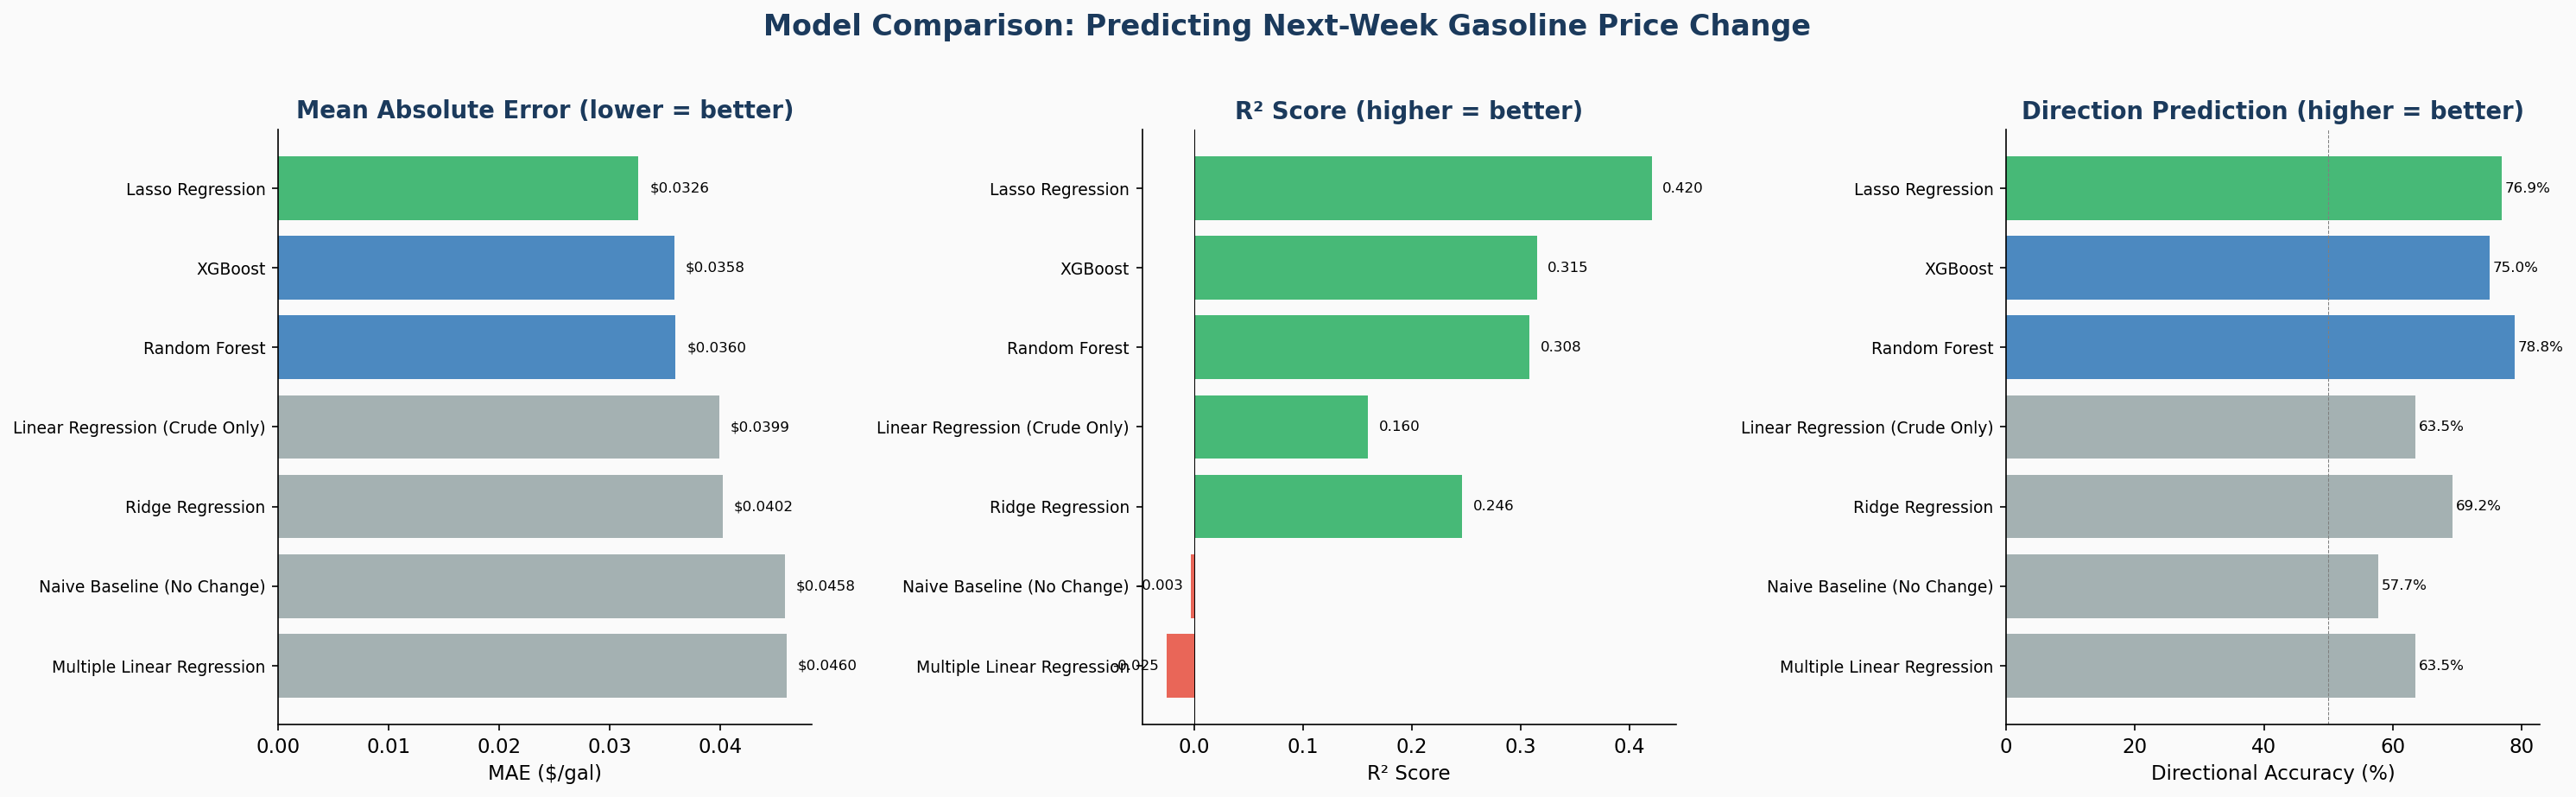

✅ Saved: outputs/models/model_comparison_chart.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Model Comparison: Predicting Next-Week Gasoline Price Change',
             fontsize=16, fontweight='bold', color='#1B3A5C', y=1.02)

res = results_df.sort_values('MAE', ascending=True)
colors = ['#27AE60' if i == 0 else '#2E75B6' if i < 3 else '#95A5A6' for i in range(len(res))]

# MAE comparison
ax = axes[0]
ax.set_facecolor('#FAFAFA')
bars = ax.barh(range(len(res)), res['MAE'], color=colors, alpha=0.85)
ax.set_yticks(range(len(res)))
ax.set_yticklabels(res['Model'], fontsize=9)
ax.set_xlabel('MAE ($/gal)')
ax.set_title('Mean Absolute Error (lower = better)', fontweight='bold', color='#1B3A5C')
for i, v in enumerate(res['MAE']):
    ax.text(v + 0.001, i, f'${v:.4f}', va='center', fontsize=8)
ax.invert_yaxis()

# R² comparison
ax = axes[1]
ax.set_facecolor('#FAFAFA')
r2_colors = ['#27AE60' if v > 0 else '#E74C3C' for v in res['R²']]
ax.barh(range(len(res)), res['R²'], color=r2_colors, alpha=0.85)
ax.set_yticks(range(len(res)))
ax.set_yticklabels(res['Model'], fontsize=9)
ax.set_xlabel('R² Score')
ax.set_title('R² Score (higher = better)', fontweight='bold', color='#1B3A5C')
ax.axvline(0, color='black', linewidth=0.5)
for i, v in enumerate(res['R²']):
    ax.text(v + 0.01 if v >= 0 else v - 0.05, i, f'{v:.3f}', va='center', fontsize=8)
ax.invert_yaxis()

# Directional accuracy comparison
ax = axes[2]
ax.set_facecolor('#FAFAFA')
ax.barh(range(len(res)), res['Dir. Acc (%)'], color=colors, alpha=0.85)
ax.set_yticks(range(len(res)))
ax.set_yticklabels(res['Model'], fontsize=9)
ax.set_xlabel('Directional Accuracy (%)')
ax.set_title('Direction Prediction (higher = better)', fontweight='bold', color='#1B3A5C')
ax.axvline(50, color='gray', linewidth=0.5, linestyle='--', label='Random guess (50%)')
for i, v in enumerate(res['Dir. Acc (%)']):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('outputs/models/model_comparison_chart.png', dpi=200, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print('Saved: outputs/models/model_comparison_chart.png')

## 12. Feature Importance (XGBoost)

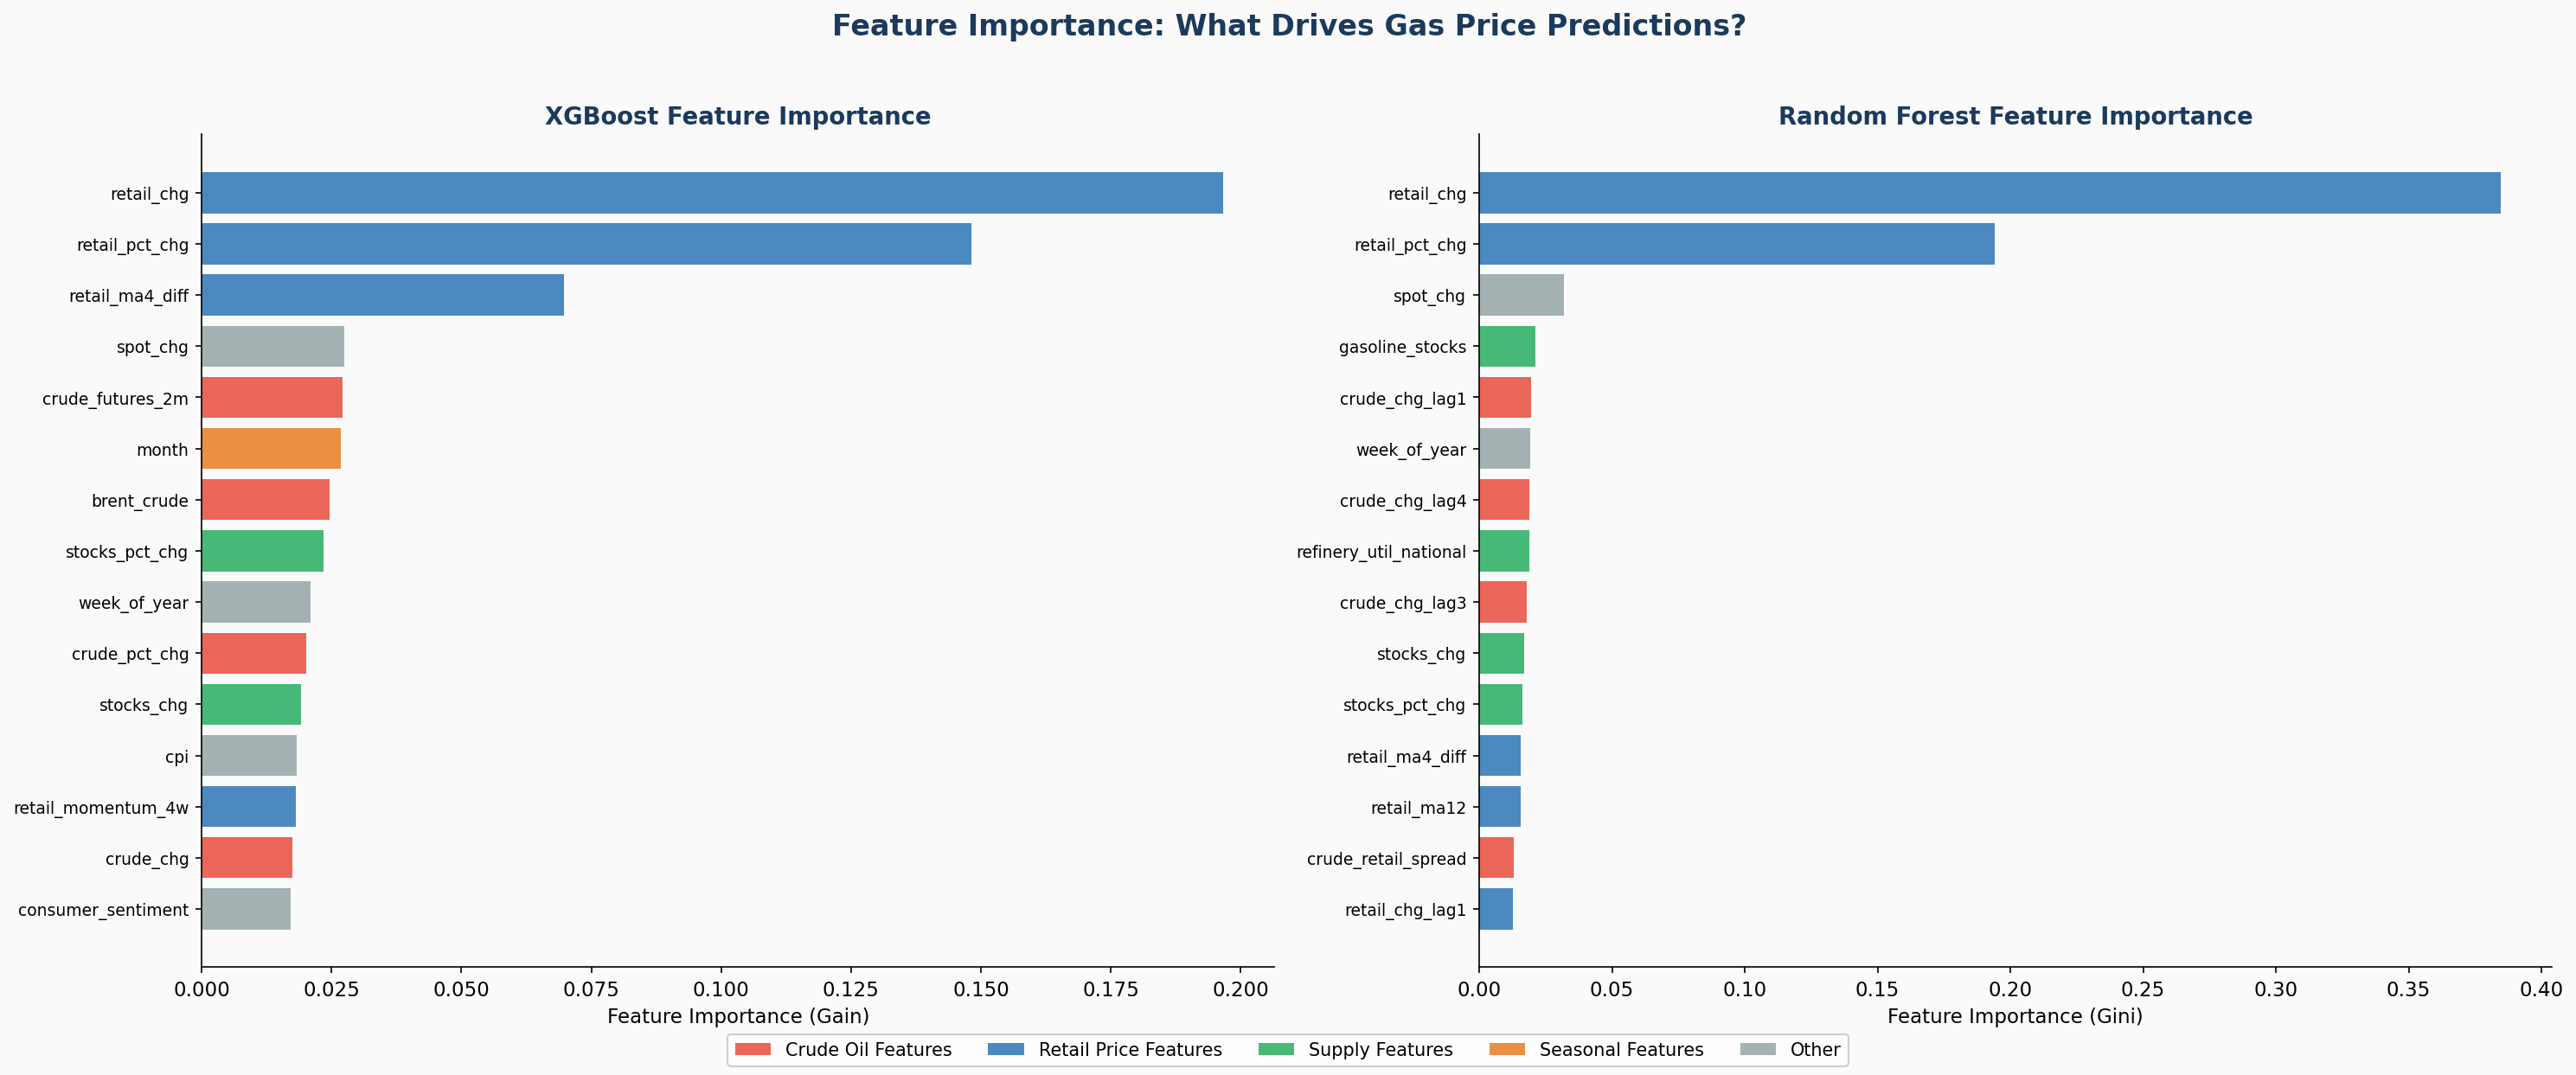

✅ Saved: outputs/models/feature_importance.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Feature Importance: What Drives Gas Price Predictions?',
             fontsize=16, fontweight='bold', color='#1B3A5C', y=1.02)

# XGBoost importance
ax = axes[0]
ax.set_facecolor('#FAFAFA')
top_n = min(15, len(xgb_importance))
top = xgb_importance.head(top_n)
colors_fi = ['#E74C3C' if 'crude' in f.lower() else '#2E75B6' if 'retail' in f.lower() 
              else '#27AE60' if 'stock' in f.lower() or 'refinery' in f.lower()
              else '#E67E22' if 'season' in f.lower() or 'month' in f.lower() or 'summer' in f.lower()
              else '#95A5A6' for f in top.index]

ax.barh(range(top_n), top.values, color=colors_fi, alpha=0.85)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top.index, fontsize=9)
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title('XGBoost Feature Importance', fontweight='bold', color='#1B3A5C')
ax.invert_yaxis()

# Random Forest importance
ax = axes[1]
ax.set_facecolor('#FAFAFA')
top_rf = rf_importance.head(top_n)
colors_rf = ['#E74C3C' if 'crude' in f.lower() else '#2E75B6' if 'retail' in f.lower() 
              else '#27AE60' if 'stock' in f.lower() or 'refinery' in f.lower()
              else '#E67E22' if 'season' in f.lower() or 'month' in f.lower() or 'summer' in f.lower()
              else '#95A5A6' for f in top_rf.index]

ax.barh(range(top_n), top_rf.values, color=colors_rf, alpha=0.85)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_rf.index, fontsize=9)
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Random Forest Feature Importance', fontweight='bold', color='#1B3A5C')
ax.invert_yaxis()

# Color legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E74C3C', alpha=0.85, label='Crude Oil Features'),
    Patch(facecolor='#2E75B6', alpha=0.85, label='Retail Price Features'),
    Patch(facecolor='#27AE60', alpha=0.85, label='Supply Features'),
    Patch(facecolor='#E67E22', alpha=0.85, label='Seasonal Features'),
    Patch(facecolor='#95A5A6', alpha=0.85, label='Other'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=5, fontsize=10, framealpha=0.95)

plt.tight_layout()
plt.subplots_adjust(bottom=0.1)
plt.savefig('outputs/models/feature_importance.png', dpi=200, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print('Saved: outputs/models/feature_importance.png')

## 13. Predictions vs Actual (Test Set)

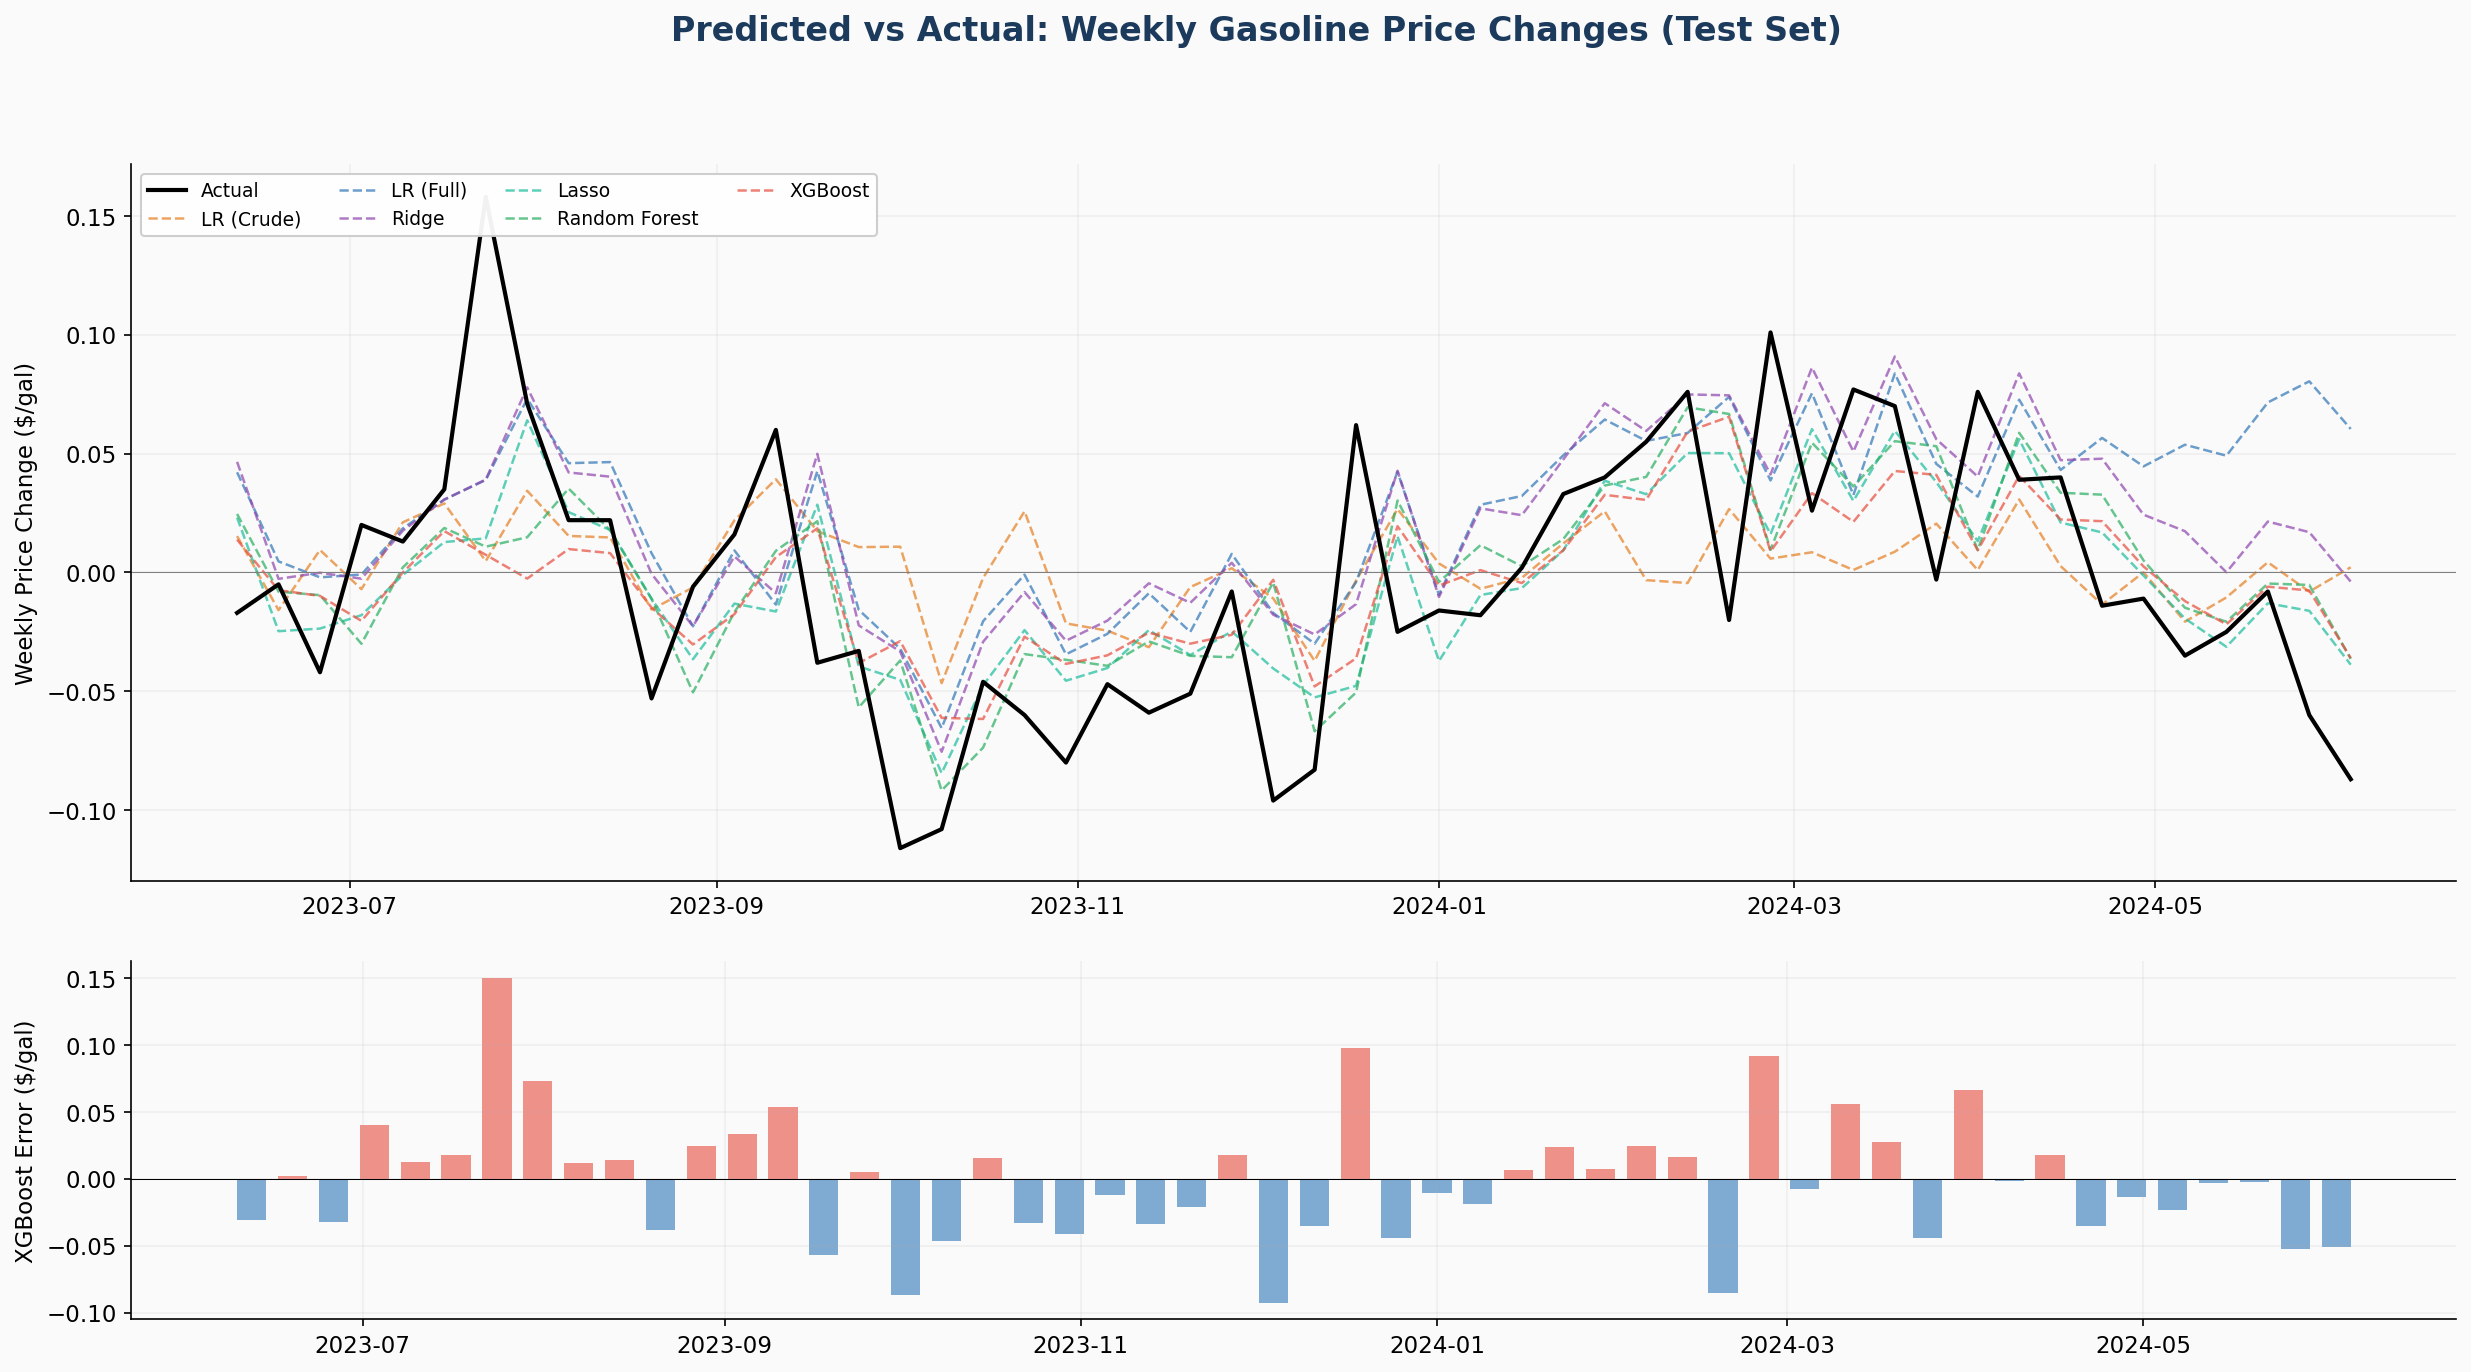

✅ Saved: outputs/models/predictions_vs_actual.png


In [18]:
# Select top 3 models + naive for the plot
top_models = results_df.head(3)['Model'].tolist()
plot_models = {}
for name, preds in all_predictions.items():
    # Map short names to full names
    for tm in top_models:
        if name.lower() in tm.lower() or tm.lower().startswith(name.lower().split(' ')[0]):
            plot_models[name] = preds
            break
    if name == 'Naive':
        plot_models['Naive'] = preds

# If we didn't match well, just take the best ones by key
if len(plot_models) < 2:
    plot_models = {k: v for k, v in list(all_predictions.items())[:4]}

fig, axes = plt.subplots(2, 1, figsize=(20, 10), gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.15})
fig.patch.set_facecolor('#FAFAFA')
fig.suptitle('Predicted vs Actual: Weekly Gasoline Price Changes (Test Set)',
             fontsize=16, fontweight='bold', color='#1B3A5C', y=0.98)

# Top panel: actual vs predicted lines
ax = axes[0]
ax.set_facecolor('#FAFAFA')
ax.grid(True, alpha=0.15)

ax.plot(y_test.index, y_test.values, color='black', linewidth=2, label='Actual', zorder=5)

model_colors = {'Naive': '#95A5A6', 'LR (Crude)': '#E67E22', 'LR (Full)': '#2E75B6', 
                'Ridge': '#8E44AD', 'Lasso': '#1ABC9C', 'Random Forest': '#27AE60',
                'XGBoost': '#E74C3C', 'SARIMAX': '#F39C12'}

for name, preds in all_predictions.items():
    if name == 'Naive':
        continue  # skip naive for readability
    color = model_colors.get(name, '#999999')
    preds_aligned = preds[:len(y_test)]
    ax.plot(y_test.index[:len(preds_aligned)], preds_aligned, 
            linewidth=1.2, alpha=0.7, color=color, linestyle='--', label=name)

ax.axhline(0, color='gray', linewidth=0.5)
ax.set_ylabel('Weekly Price Change ($/gal)')
ax.legend(fontsize=9, ncol=4, loc='upper left', framealpha=0.95)

# Bottom panel: prediction errors for best model
ax = axes[1]
ax.set_facecolor('#FAFAFA')
ax.grid(True, alpha=0.15)

# Use XGBoost errors (or best model)
best_name = 'XGBoost' if 'XGBoost' in all_predictions else list(all_predictions.keys())[-1]
best_preds = all_predictions[best_name][:len(y_test)]
errors = y_test.values[:len(best_preds)] - best_preds

error_colors = ['#E74C3C' if e > 0 else '#2E75B6' for e in errors]
ax.bar(y_test.index[:len(errors)], errors, color=error_colors, alpha=0.6, width=5)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel(f'{best_name} Error ($/gal)')
ax.set_xlabel('')

plt.tight_layout()
plt.savefig('outputs/models/predictions_vs_actual.png', dpi=200, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print('Saved: outputs/models/predictions_vs_actual.png')

## 14. Cross-Validation (Time Series)

In [19]:
# Time series cross-validation for the best model (XGBoost)
tscv = TimeSeriesSplit(n_splits=5)

cv_scores = {'MAE': [], 'RMSE': [], 'Dir_Acc': []}

print('Time Series Cross-Validation (5-fold) — XGBoost')
print('=' * 60)

for fold, (train_idx, val_idx) in enumerate(tscv.split(model_df)):
    X_cv_train = model_df.iloc[train_idx][features]
    y_cv_train = model_df.iloc[train_idx]['target']
    X_cv_val = model_df.iloc[val_idx][features]
    y_cv_val = model_df.iloc[val_idx]['target']
    
    cv_model = xgb.XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
        random_state=42, verbosity=0,
    )
    cv_model.fit(X_cv_train, y_cv_train, verbose=False)
    cv_pred = cv_model.predict(X_cv_val)
    
    mae = mean_absolute_error(y_cv_val, cv_pred)
    rmse = np.sqrt(mean_squared_error(y_cv_val, cv_pred))
    dir_acc = ((y_cv_val > 0).astype(int) == (cv_pred > 0).astype(int)).mean() * 100
    
    cv_scores['MAE'].append(mae)
    cv_scores['RMSE'].append(rmse)
    cv_scores['Dir_Acc'].append(dir_acc)
    
    print(f'  Fold {fold+1}: MAE=${mae:.4f}  RMSE=${rmse:.4f}  Dir={dir_acc:.1f}%  '
          f'(train={len(train_idx)}, val={len(val_idx)})')

print(f'\nMean ± Std:')
print(f'  MAE:  ${np.mean(cv_scores["MAE"]):.4f} ± ${np.std(cv_scores["MAE"]):.4f}')
print(f'  RMSE: ${np.mean(cv_scores["RMSE"]):.4f} ± ${np.std(cv_scores["RMSE"]):.4f}')
print(f'  Dir:  {np.mean(cv_scores["Dir_Acc"]):.1f}% ± {np.std(cv_scores["Dir_Acc"]):.1f}%')

Time Series Cross-Validation (5-fold) — XGBoost
  Fold 1: MAE=$0.0404  RMSE=$0.0493  Dir=61.9%  (train=162, val=160)
  Fold 2: MAE=$0.0375  RMSE=$0.0477  Dir=63.7%  (train=322, val=160)
  Fold 3: MAE=$0.0315  RMSE=$0.0428  Dir=71.2%  (train=482, val=160)
  Fold 4: MAE=$0.0230  RMSE=$0.0300  Dir=75.6%  (train=642, val=160)
  Fold 5: MAE=$0.0432  RMSE=$0.0670  Dir=68.8%  (train=802, val=160)

Mean ± Std:
  MAE:  $0.0351 ± $0.0072
  RMSE: $0.0474 ± $0.0119
  Dir:  68.2% ± 5.0%


## 15. Cumulative Profit Simulation

If you followed each model's directional prediction (buy when it says up, sell when it says down), how much would you save/earn vs. naive?

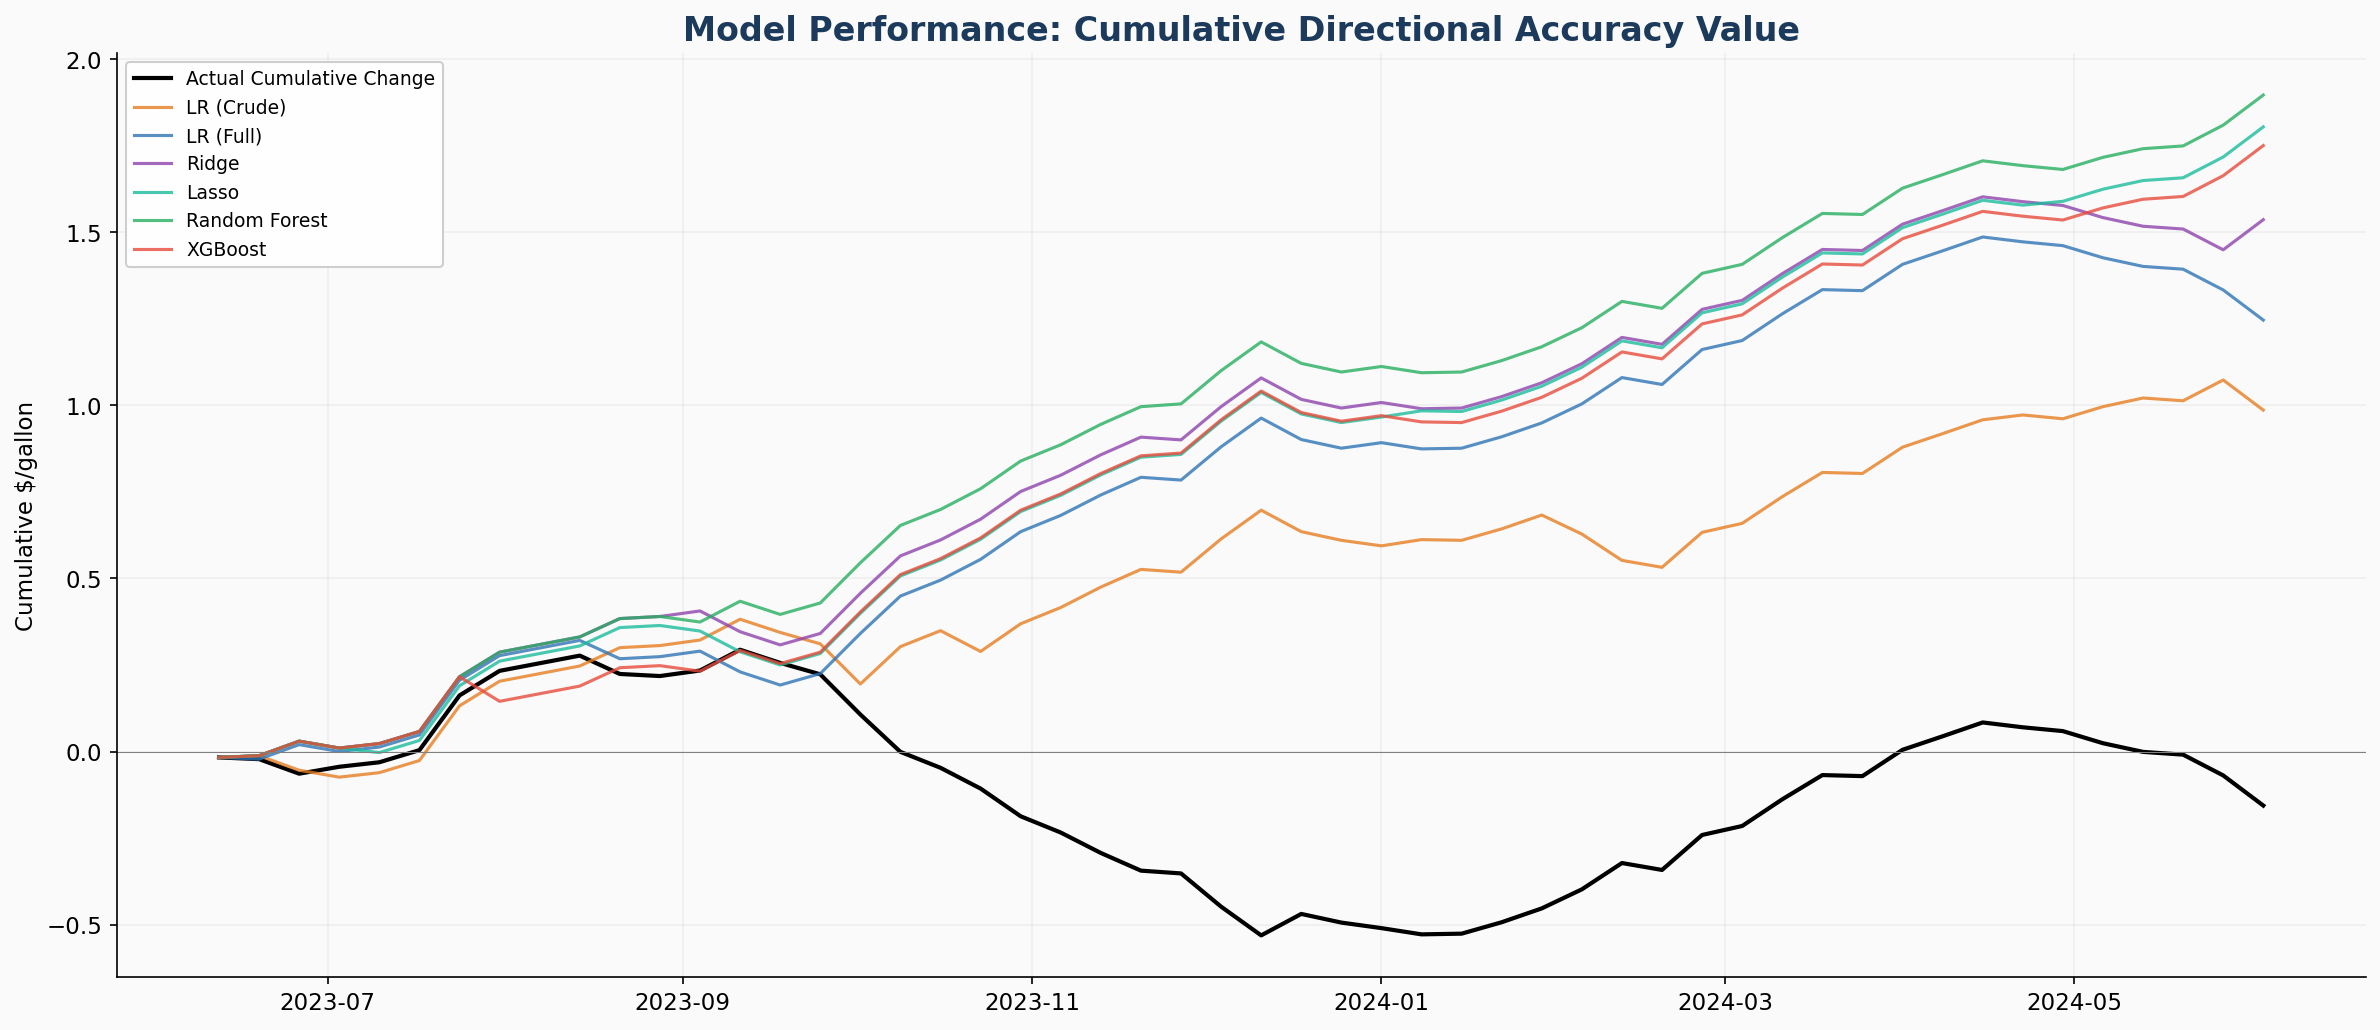

✅ Saved: outputs/models/cumulative_performance.png


In [20]:
fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')
ax.grid(True, alpha=0.15)

# Cumulative actual price change
actual_cumsum = np.cumsum(y_test.values)
ax.plot(y_test.index, actual_cumsum, color='black', linewidth=2, label='Actual Cumulative Change')

# For each model: cumulative "profit" if you correctly predicted direction
for name, preds in all_predictions.items():
    if name == 'Naive':
        continue
    preds_aligned = np.array(preds[:len(y_test)])
    # "Profit" = actual change when prediction direction is correct, 0 otherwise
    correct = (preds_aligned > 0) == (y_test.values > 0)
    profit = np.where(correct, np.abs(y_test.values), -np.abs(y_test.values))
    cum_profit = np.cumsum(profit)
    
    color = model_colors.get(name, '#999999')
    ax.plot(y_test.index[:len(cum_profit)], cum_profit, 
            linewidth=1.5, alpha=0.8, color=color, label=f'{name}')

ax.axhline(0, color='gray', linewidth=0.5)
ax.set_ylabel('Cumulative $/gallon')
ax.set_title('Model Performance: Cumulative Directional Accuracy Value',
             fontsize=16, fontweight='bold', color='#1B3A5C')
ax.legend(fontsize=9, framealpha=0.95)

plt.tight_layout()
plt.savefig('outputs/models/cumulative_performance.png', dpi=200, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print('Saved: outputs/models/cumulative_performance.png')

## 16. Summary & Key Takeaways

In [21]:
print('=' * 70)
print('FINAL MODEL COMPARISON SUMMARY')
print('=' * 70)
print()
print(results_df.to_string(index=False, float_format='%.4f'))
print()

best = results_df.iloc[0]
naive_row = results_df[results_df['Model'].str.contains('Naive')].iloc[0]

print(f'BEST MODEL: {best["Model"]}')
print(f'  MAE:  ${best["MAE"]:.4f}/gallon (vs naive ${naive_row["MAE"]:.4f})')
print(f'  RMSE: ${best["RMSE"]:.4f}/gallon')
print(f'  R²:   {best["R²"]:.4f}')
print(f'  Directional Accuracy: {best["Dir. Acc (%)"]:.1f}% (vs naive {naive_row["Dir. Acc (%)"]:.1f}%)')
print(f'  MAE Improvement over naive: {((naive_row["MAE"] - best["MAE"]) / naive_row["MAE"] * 100):.1f}%')

print(f'\nTOP 5 MOST IMPORTANT FEATURES (XGBoost):')
for i, (feat, imp) in enumerate(xgb_importance.head(5).items()):
    print(f'  {i+1}. {feat} ({imp:.4f})')

print(f'\nCROSS-VALIDATION RESULTS (XGBoost, 5-fold):')
print(f'  MAE:  ${np.mean(cv_scores["MAE"]):.4f} ± ${np.std(cv_scores["MAE"]):.4f}')
print(f'  Dir Accuracy: {np.mean(cv_scores["Dir_Acc"]):.1f}% ± {np.std(cv_scores["Dir_Acc"]):.1f}%')

print(f'\nFILES SAVED:')
for f in sorted(Path('outputs/models').glob('*')):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<40} {size_kb:.0f} KB')

print(f'\n Modeling complete!')

FINAL MODEL COMPARISON SUMMARY

                         Model    MAE   RMSE      R²  Dir. Acc (%)  MAPE (%)
              Lasso Regression 0.0326 0.0430  0.4205       76.9231  129.0397
                       XGBoost 0.0358 0.0468  0.3151       75.0000  125.8277
                 Random Forest 0.0360 0.0470  0.3081       78.8462  142.4317
Linear Regression (Crude Only) 0.0399 0.0518  0.1599       63.4615  104.8740
              Ridge Regression 0.0402 0.0491  0.2462       69.2308  174.2572
    Naive Baseline (No Change) 0.0458 0.0566 -0.0028       57.6923  100.0000
    Multiple Linear Regression 0.0460 0.0573 -0.0252       63.4615  204.0849

BEST MODEL: Lasso Regression
  MAE:  $0.0326/gallon (vs naive $0.0458)
  RMSE: $0.0430/gallon
  R²:   0.4205
  Directional Accuracy: 76.9% (vs naive 57.7%)
  MAE Improvement over naive: 28.9%

TOP 5 MOST IMPORTANT FEATURES (XGBoost):
  1. retail_chg (0.1967)
  2. retail_pct_chg (0.1482)
  3. retail_ma4_diff (0.0697)
  4. spot_chg (0.0275)
  5. crude